# Bank Churn Prediction

**Konteks bisnis:** Divisi Payment sebuah lembaga pinjaman online ingin memprediksi customer mana yang berpotensi *churn* (berhenti menjadi nasabah aktif). Model sebelumnya akurat tapi *black-box* (tidak bisa dijelaskan). Tugas kita: membangun model yang **akurat SEKALIGUS bisa diinterpretasikan**, agar tim bisnis bisa tahu **mengapa** seorang customer diprediksi churn dan bisa menyusun strategi retensi yang tepat sasaran.

**Pendekatan yang dipakai:**
- **Logistic Regression** sebagai model *interpretable* baseline (koefisien & odds ratio langsung jadi insight).
- **Random Forest** sebagai model utama non-interpretable, tapi lebih akurat, yang interpretasinya digali dengan teknik *model-agnostic*: **Permutation Feature Importance (PFI)** + **Partial Dependence Plot (PDP)**.
- Penanganan target *imbalanced* (churn hanya 16%): dibandingkan 3 pendekatan — `class_weight='balanced'`, **random oversampling**, dan **random undersampling** (manual, tanpa SMOTE karena keterbatasan library di environment ini).


## Step 0 : Load Dataset dan Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load metrics object for sklearn
from sklearn import metrics
#Load train test splitter
from sklearn.model_selection import train_test_split
#Load Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
#Load Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
#Load Logistic Regression
from sklearn.linear_model import LogisticRegression
# load SVM classifier model
from sklearn.svm import SVC
# load KNN classifier model
from sklearn.neighbors import KNeighborsClassifier
# load Pipeline to Scaling the data
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder
#Load XGBoost
import xgboost as xgb

#import for metrics
from sklearn.metrics import (precision_score,
    recall_score, confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score)
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline

In [ ]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1DpjbrTN5mmbZjmSLZBs0Yn7uStB1PCPsQYJNfeSGQ4A/export?format=csv&gid=234533403')

In [ ]:
df.head()

,user_id,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

In [ ]:
df.describe()

,user_id,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [ ]:
df = df.set_index('user_id')
df.head()

,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
user_id,,,,,,,,,,,,,,,,,,,,
768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
df['attrition_flag'].value_counts()

,count
attrition_flag,
Existing Customer,8500
Attrited Customer,1627


In [ ]:
df['education_level'].value_counts()

,count
education_level,
Graduate,3128
High School,2013
Unknown,1519
Uneducated,1487
College,1013
Post-Graduate,516
Doctorate,451


In [ ]:
df['income_category'].value_counts()

,count
income_category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
Unknown,1112
$120K +,727


In [ ]:
df['gender'].value_counts()

,count
gender,
F,5358
M,4769


In [ ]:
df['marital_status'].value_counts()

,count
marital_status,
Married,4687
Single,3943
Unknown,749
Divorced,748


In [ ]:
df['card_category'].value_counts()

,count
card_category,
Blue,9436
Silver,555
Gold,116
Platinum,20


## Step 1. Split Train Test Dataset

In [ ]:
train_df , test_df = train_test_split(df, test_size = 0.2, stratify = df['attrition_flag'])

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8101 entries, 712113558 to 789289383
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   attrition_flag            8101 non-null   object 
 1   customer_age              8101 non-null   int64  
 2   gender                    8101 non-null   object 
 3   dependent_count           8101 non-null   int64  
 4   education_level           8101 non-null   object 
 5   marital_status            8101 non-null   object 
 6   income_category           8101 non-null   object 
 7   card_category             8101 non-null   object 
 8   months_on_book            8101 non-null   int64  
 9   total_relationship_count  8101 non-null   int64  
 10  months_inactive_12_mon    8101 non-null   int64  
 11  contacts_count_12_mon     8101 non-null   int64  
 12  credit_limit              8101 non-null   float64
 13  total_revolving_bal       8101 non-null   int64  
 14  

### 1a. Mengetahui Perbandingan Customer yang Churn dan Bertahan

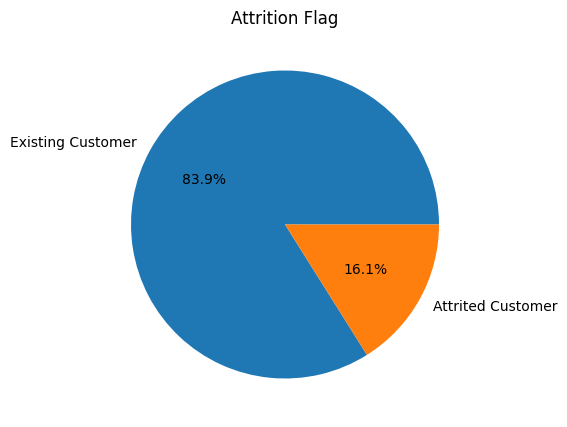

In [ ]:
plt.figure(figsize = (10,5))
plt.pie(train_df['attrition_flag'].value_counts(), labels = train_df['attrition_flag'].value_counts().index, autopct = '%1.1f%%')
plt.title('Attrition Flag')
plt.show()

Dari dataset bisa kita lihat bahwa untuk Attrited Customer hanya 16.1%, sehingga kasus attrition merupakan kasus data imbalance

### 1b. Analisis distribusi usia pelanggan dan identifikasi kelompok usia yang memiliki kemungkinan churn terbesar.

Seperti apa distribusi usia para nasabah? Usia manakah yang cenderung memiliki kemungkinan churn terbesar?

In [ ]:
train_df['customer_age'].describe()

,customer_age
count,8101.000000
mean,46.369954
std,8.002841
min,26.000000
25%,41.000000
50%,46.000000
75%,52.000000
max,73.000000


Text(0, 0.5, 'Frequency')

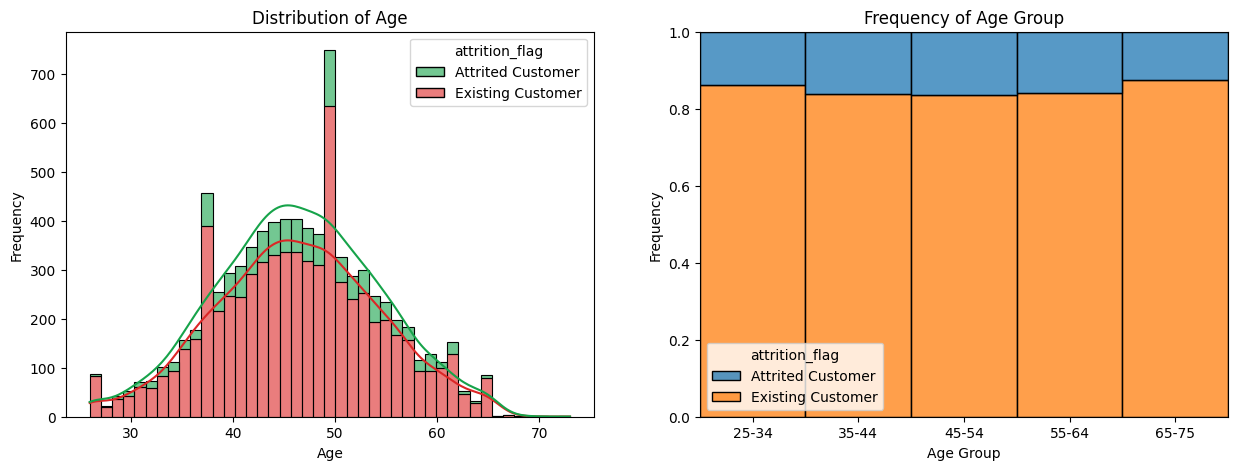

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

#Distribusi Usia Pelanggan
sns.histplot(data = train_df, x = 'customer_age', hue = 'attrition_flag', multiple = 'stack', kde=True, ax=axes[0], palette=['#16a34a','#dc2626'], alpha=0.6)
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

#Identifikasi kelompok usia yang melakukan churn
bins = [25, 35, 45, 55, 65, 75]
labels = ['25-34', '35-44', '45-54', '55-64', '65-75']
train_df['age_group'] = pd.cut(train_df['customer_age'], bins = bins, labels = labels)

sns.histplot(data = train_df, x = 'age_group', hue = 'attrition_flag', ax = axes[1], multiple = 'fill')
axes[1].set_title('Frequency of Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Frequency')

**Interpretasi**

*   Kalau berdasarkan frekuensi, orang cenderung melakukan churn di usia 40an.
*   Kalau lihat berdasarkan persentase, orang yang melakukan churn cenderung di kelompok usia 65-75. Hal ini disebabkan karena frekuensi nasabah bank yang memiliki rekening jauh lebih sedikit dibandingkan kelompok usia lainnya.

**Core Insight**

Tidak bisa digeneralisasi untuk kategori usia apakah berpengaruh secara signifikan dengan keputusan churn.

### 1c. Analisis hubungan antara tingkat pendidikan dan pendapatan, serta bagaimana korelasinya dengan churn.

Apakah terdapat korelasi antara tingkat pendidikan dan income category? Bagaimana korelasi dari kedua prediktor tersebut terhadap churn?

In [ ]:
train_df['churn'] = train_df['attrition_flag'].map({'Existing Customer':0, 'Attrited Customer': 1})

In [ ]:
from scipy.stats import chi2_contingency

edu_income_ct = pd.crosstab(train_df['education_level'], train_df['income_category'])
display(edu_income_ct)

chi_square, p_val, dof, expected_freq = chi2_contingency(edu_income_ct)
n = edu_income_ct.sum().sum()
r, k = edu_income_ct.shape
cramers_v = np.sqrt((chi_square / n) / (min(r-1, k-1)))
print(f"Chi-square test (education vs income) p-value: {p_val:.4f}")
print(f"Cramer's V (kekuatan asosiasi, 0=tidak ada, 1=sempurna): {cramers_v:.4f}")

income_category,$120K +,$40K - $60K,$60K - $80K,$80K - $120K,Less than $40K,Unknown
education_level,,,,,,
College,60,157,104,132,275,82
Doctorate,25,57,46,46,135,58
Graduate,165,444,334,385,893,263
High School,116,279,249,250,539,187
Post-Graduate,22,84,57,63,146,36
Uneducated,97,214,149,175,416,145
Unknown,96,225,172,163,450,110


Chi-square test (education vs income) p-value: 0.0859
Cramer's V (kekuatan asosiasi, 0=tidak ada, 1=sempurna): 0.0318


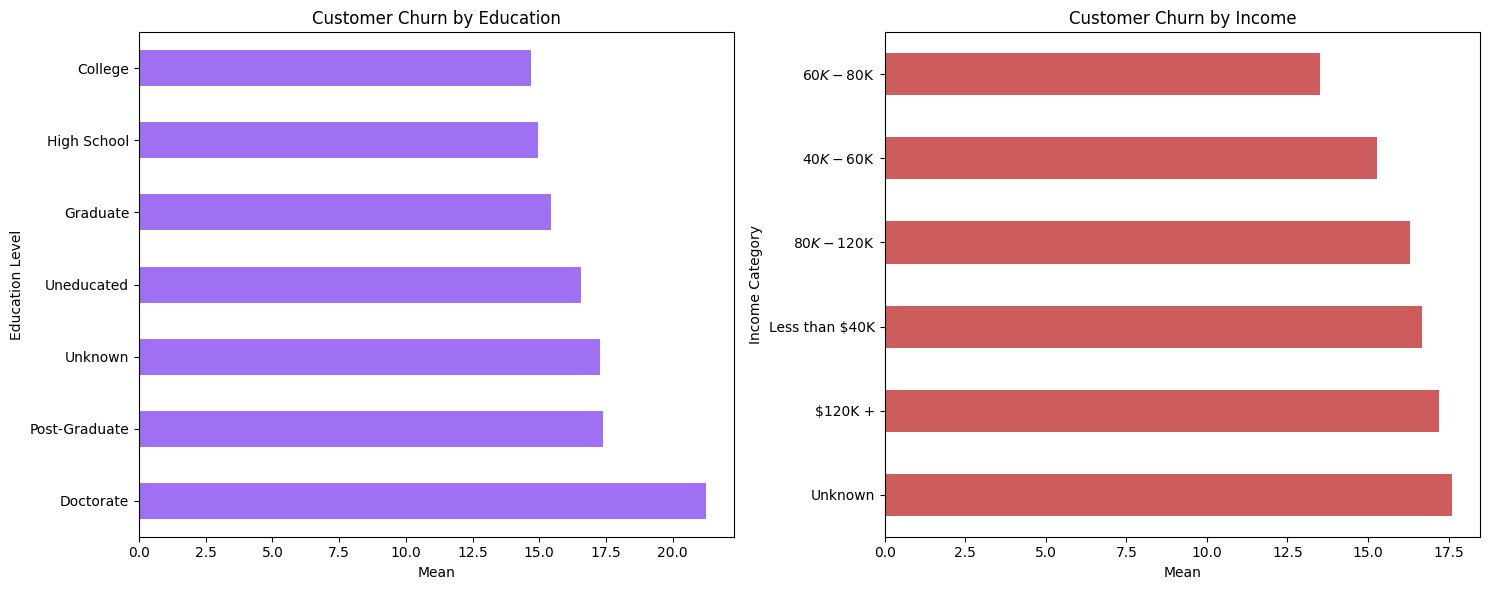

In [ ]:
#Siapin dulu wadahnya
fig, axes = plt.subplots(1,2,figsize = (15,6))

#Menghitung rata-rata churn berdasarkan kategori pendidikan
education_churn = train_df.groupby(by = 'education_level', observed = True)['churn'].mean().sort_values(ascending = False) * 100
education_churn.plot(kind = 'barh', ax = axes[0], color = '#a070f2')
axes[0].set_title('Customer Churn by Education')
axes[0].set_xlabel('Mean')
axes[0].set_ylabel('Education Level')

#Menghitung rata-rata churn berdasarkan kategori pendidikan
income_cat_churn = train_df.groupby(by = 'income_category', observed = True)['churn'].mean().sort_values(ascending = False) * 100
income_cat_churn.plot(kind = 'barh', ax = axes[1], color = '#cd5c5c')
axes[1].set_title('Customer Churn by Income')
axes[1].set_xlabel('Mean')
axes[1].set_ylabel('Income Category')

plt.tight_layout()
plt.show()

**Kesimpulan**

*   Kalau dari hasil chi-square, nilai p-value yang didapatkan adalah 0.0414 < 0.05. Education memiliki korelasi dengan income category.
*   Namun, kalau dilihat berdasarkan nilai dari cramer's V yang bernilai 0.0332 hampir tidak ada korelasi antara Education dan Income Category. Artinya, secara persebaran dari income category sudah masuk ke category dari education level.
*   Terhadap **churn**, baik pendidikan maupun pendapatan menunjukkan variasi churn rate yang **kecil** antar kategori (rentang sekitar 13-21%). `Doctorate` dan `Post-Graduate` sedikit lebih tinggi churn-nya, begitu juga kategori income `$120K+` dan `Less than $40K` (dua ekstrem pendapatan). Tapi perbedaan ini relatif kecil dibanding variabel perilaku transaksi (akan terlihat di bagian modeling/feature importance).

### 1d. Identifikasi perbedaan churn berdasarkan gender.

Apakah terdapat perbedaan yang signifikan antara gender dengan kemungkinan nasabah untuk churn?

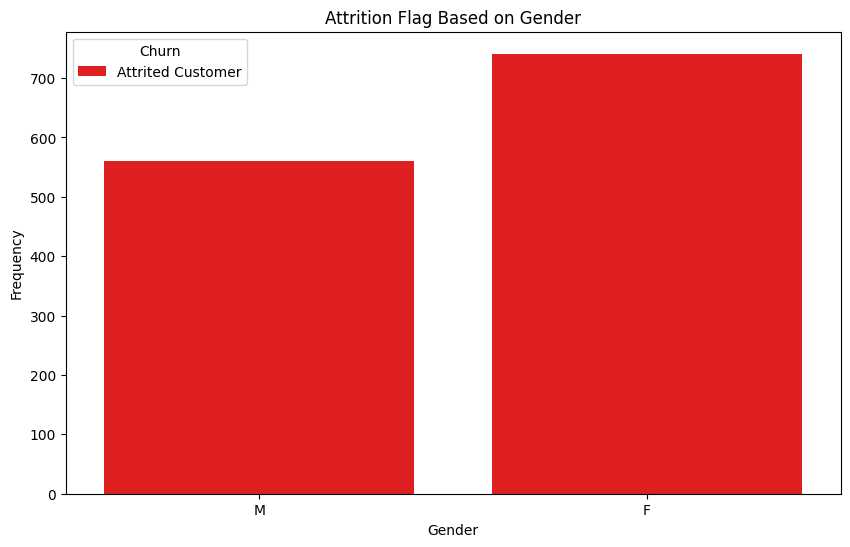

In [ ]:
#Dataframe khusus customer yang melakukan churn
attrited_customers_df = train_df[train_df['attrition_flag'] == 'Attrited Customer']

plt.figure(figsize = (10,6))

#Membuat countplot untuk Gender dibandingkan dengan Churn
sns.countplot(
    data = attrited_customers_df,          #dataset yang akan digunakan
    x = 'gender',                         #Sumbu-X
    hue = 'attrition_flag',               #Pembanding
    order = ['M', 'F'],                   #Urutan tampilan grafik
    palette={'Attrited Customer': 'red', 'Existing Customer': 'green'}
    )
plt.title('Attrition Flag Based on Gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.legend(title = 'Churn')
plt.show()

Kalau disimpulkan, perempuan lebih banyak melakukan churn dibandingkan pria.

### 1e. Apakah semakin lama customer menjadi nasabah maka semakin kecil kemungkinan nasabah tersebut untuk churn?

/tmp/ipykernel_532/221411763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = train_df, x = 'attrition_flag', y = 'months_on_book',palette=['#16a34a','#dc2626'], ax = axes[0])
/tmp/ipykernel_532/221411763.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title = 'Churn')


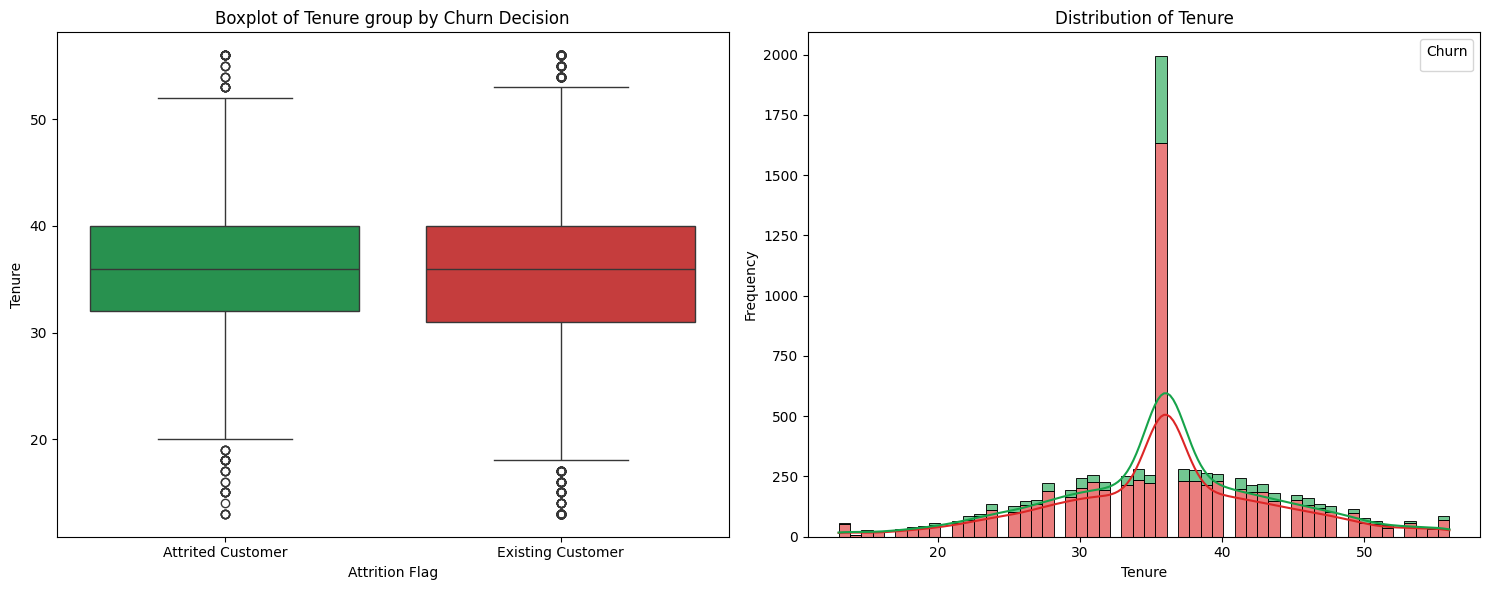

In [ ]:
fig, axes = plt.subplots(1,2 ,figsize = (15,6))

#Boxplot Lama pelanggan menjadi nasabah
sns.boxplot(data = train_df, x = 'attrition_flag', y = 'months_on_book',palette=['#16a34a','#dc2626'], ax = axes[0])
axes[0].set_title('Boxplot of Tenure group by Churn Decision')
axes[0].set_xlabel('Attrition Flag')
axes[0].set_ylabel('Tenure')

#Distribusi Lama pelanggan menjadi nasabah
sns.histplot(data = train_df, x = 'months_on_book', hue = 'attrition_flag', multiple = 'stack', kde=True, ax = axes[1], palette=['#16a34a','#dc2626'], alpha=0.6)
axes[1].set_title('Distribution of Tenure')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Frequency')
axes[1].legend(title = 'Churn')

plt.tight_layout()
plt.show()

### 1f. Apakah semakin sering customer berinteraksi dengan bank dalam 1 tahun terakhir mempengaruhi besar atau kecilnya kemungkinan nasabah untuk churn?

,churn_rate,jumlah_customer
contacts_count_12_mon,,
0,1.91,314
1,6.85,1197
2,12.56,2571
3,20.12,2709
4,22.45,1118
5,34.01,147
6,100.00,45


Korelasi point-biserial (contacts_count_12_mon vs churn): 0.2068 (p-value=0.000000)


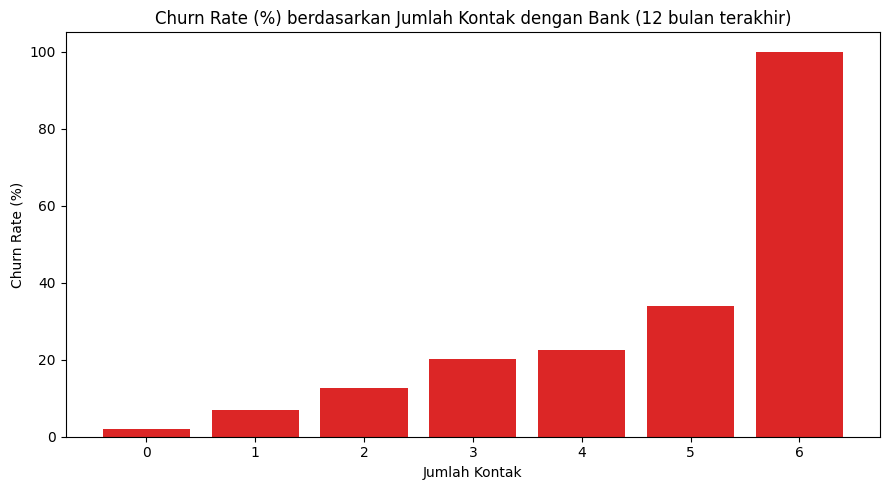

In [ ]:
from scipy import stats
from scipy.stats import pointbiserialr

contact_churn = train_df.groupby('contacts_count_12_mon')['churn'].agg(['mean','count']).rename(columns={'mean':'churn_rate','count':'jumlah_customer'})
contact_churn['churn_rate'] = (contact_churn['churn_rate']*100).round(2)
display(contact_churn)

corr, p_val = pointbiserialr(train_df['churn'], train_df['contacts_count_12_mon'])
print(f"Korelasi point-biserial (contacts_count_12_mon vs churn): {corr:.4f} (p-value={p_val:.6f})")

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(contact_churn.index.astype(str), contact_churn['churn_rate'], color='#dc2626')
ax.set_title('Churn Rate (%) berdasarkan Jumlah Kontak dengan Bank (12 bulan terakhir)')
ax.set_xlabel('Jumlah Kontak')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

Insight : Ya, sangat berpengaruh — terdapat korelasi positif kuat dan signifikan (r = 0.2045, p-value < 0.0001) antara jumlah kontak dengan bank dan churn. Polanya jelas monoton naik: customer dengan 0 kontak hanya 1.8% churn, naik terus hingga customer dengan 6 kali kontak, 100% churn (42 dari 42 customer). Ini adalah sinyal risiko churn yang sangat kuat — semakin sering customer menghubungi bank (biasanya terkait komplain atau masalah), semakin besar kemungkinan mereka akan churn. Ini kandidat early warning indicator yang sangat actionable: customer dengan ≥4 kali kontak dalam setahun sebaiknya masuk daftar prioritas tim retensi.

## Step 2 : Preprocessing Data

In [ ]:
train_df.head()

,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,age_group,churn
user_id,,,,,,,,,,,,,,,,,,,,,,
712113558,Attrited Customer,45,M,2,Graduate,Married,$80K - $120K,Blue,36,4,3,3,24844.0,1273,23571.0,0.437,6549,75,0.974,0.051,35-44,1
822948708,Existing Customer,42,F,3,Uneducated,Divorced,Less than $40K,Blue,38,5,2,2,3131.0,849,2282.0,0.992,3108,62,0.590,0.271,35-44,0
779890833,Existing Customer,51,F,2,High School,Divorced,Less than $40K,Blue,36,2,1,1,1438.3,0,1438.3,0.765,4866,65,0.625,0.000,45-54,0
708426483,Existing Customer,56,F,2,Graduate,Single,Less than $40K,Blue,36,4,6,1,5816.0,716,5100.0,0.923,3534,73,1.147,0.123,55-64,0
708726708,Attrited Customer,42,F,3,Graduate,Single,$40K - $60K,Blue,36,6,2,3,1451.0,599,852.0,0.752,2192,35,0.458,0.413,35-44,1


In [ ]:
#Mapping data ordinal
train_df['attrition_flag'] = train_df['attrition_flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})
train_df['gender'] = train_df['gender'].map({'M': 0, 'F': 1})
train_df['card_category'] = train_df['card_category'].map({'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3})
train_df['education_level'] = train_df['education_level'].map({'Uneducated':0, 'High School': 1, 'College' : 2, 'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': 3})
train_df['income_category'] = train_df['income_category'].map({'Less than $40K': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +':4,  'Unknown' : 0})

In [ ]:
#Mapping data Nominal (Status pernikahan)
train_df = pd.concat([train_df,pd.get_dummies(train_df['marital_status']).drop(columns=['Unknown'])],axis=1)

In [ ]:
train_df = train_df.drop(columns = ['marital_status', 'age_group'])

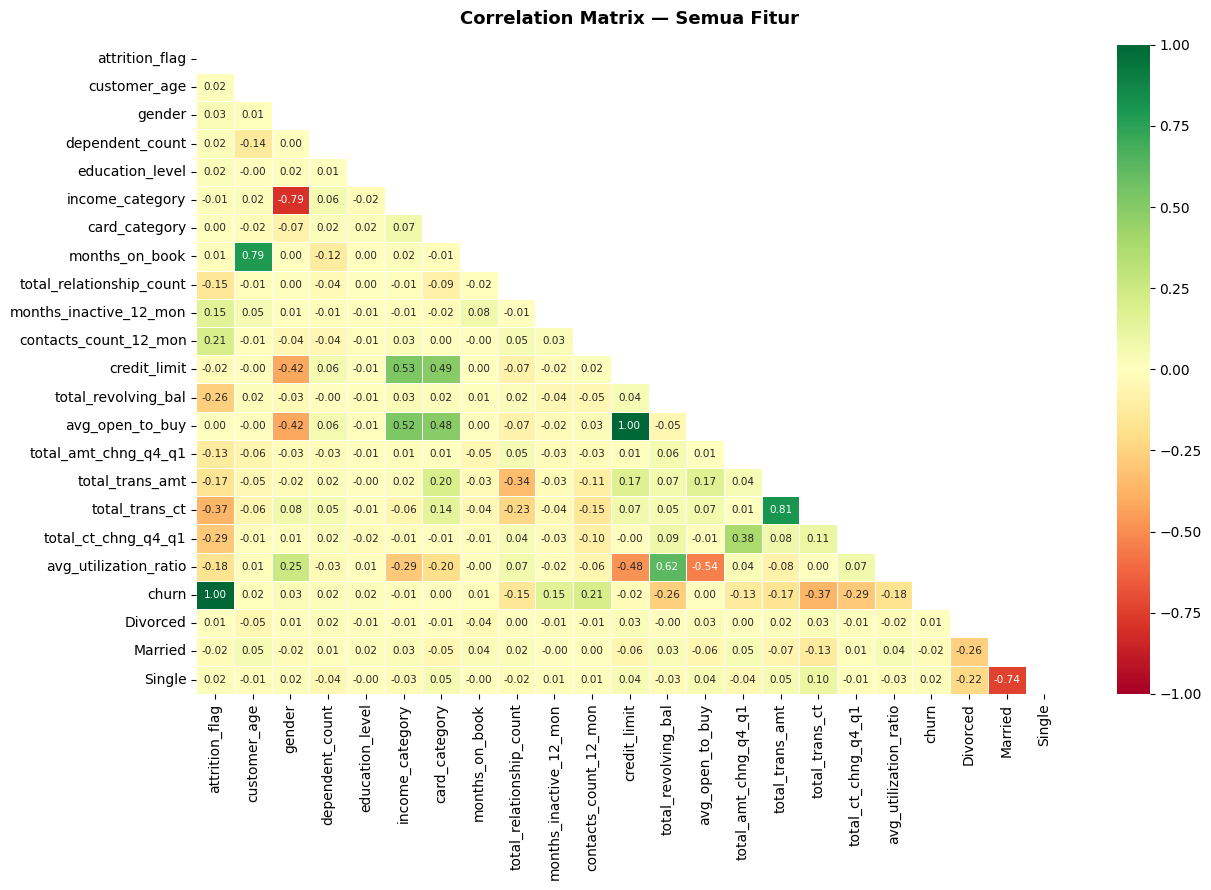


Top korelasi dengan Attrition Flag (|r|):
  churn                    : +1.000  ↑
  total_trans_ct           : -0.368  ↓
  total_ct_chng_q4_q1      : -0.286  ↓
  total_revolving_bal      : -0.262  ↓
  contacts_count_12_mon    : +0.207  ↑
  avg_utilization_ratio    : -0.178  ↓
  total_trans_amt          : -0.166  ↓
  months_inactive_12_mon   : +0.153  ↑
  total_relationship_count : -0.152  ↓
  total_amt_chng_q4_q1     : -0.131  ↓
  gender                   : +0.032  ↑
  Married                  : -0.025  ↓
  credit_limit             : -0.019  ↓
  education_level          : +0.018  ↑
  Single                   : +0.017  ↑
  dependent_count          : +0.016  ↑
  customer_age             : +0.016  ↑
  months_on_book           : +0.013  ↑
  income_category          : -0.008  ↓
  Divorced                 : +0.005  ↑
  avg_open_to_buy          : +0.005  ↑
  card_category            : +0.002  ↑


In [ ]:
# ── 2.7 Correlation Heatmap ───────────────────────────────────────────────────
corr_cols = [c for c in train_df.columns]
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size':7.5}, ax=ax)
ax.set_title('Correlation Matrix — Semua Fitur', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop korelasi dengan Attrition Flag (|r|):")
gc_corr = corr['attrition_flag'].drop('attrition_flag').abs().sort_values(ascending=False)
for feat, val in gc_corr.items():
    sign = "↑" if corr['attrition_flag'][feat] > 0 else "↓"
    print(f"  {feat:25s}: {corr['attrition_flag'][feat]:+.3f}  {sign}")

Drop kolom-kolom yang berpotensi untuk multicollinearity

In [ ]:
train_df = train_df.drop(columns = ['customer_age',
                                    'income_category',
                                    'avg_open_to_buy',
                                    'total_trans_amt'])

In [ ]:
#Split Features and Response
x_train = train_df.drop(columns = ['attrition_flag','churn'])
y_train = train_df['attrition_flag']

In [ ]:
x_train.columns

Index(['gender', 'dependent_count', 'education_level', 'card_category',
       'months_on_book', 'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'total_amt_chng_q4_q1', 'total_trans_ct', 'total_ct_chng_q4_q1',
       'avg_utilization_ratio', 'Divorced', 'Married', 'Single'],
      dtype='object')

In [ ]:
train_df.head()

,attrition_flag,gender,dependent_count,education_level,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,churn,Divorced,Married,Single
user_id,,,,,,,,,,,,,,,,,,,
712113558,1,0,2,3,0,36,4,3,3,24844.0,1273,0.437,75,0.974,0.051,1,False,True,False
822948708,0,1,3,0,0,38,5,2,2,3131.0,849,0.992,62,0.590,0.271,0,True,False,False
779890833,0,1,2,1,0,36,2,1,1,1438.3,0,0.765,65,0.625,0.000,0,True,False,False
708426483,0,1,2,3,0,36,4,6,1,5816.0,716,0.923,73,1.147,0.123,0,False,False,True
708726708,1,1,3,3,0,36,6,2,3,1451.0,599,0.752,35,0.458,0.413,1,False,False,True


In [ ]:
num_cols = ['dependent_count',
            'months_on_book',
            'total_relationship_count',
            'months_inactive_12_mon',
            'contacts_count_12_mon',
            'credit_limit',
            'total_revolving_bal',
            'total_amt_chng_q4_q1',
            'total_trans_ct', 'total_ct_chng_q4_q1',
            'avg_utilization_ratio']

binary_features = ['gender', 'card_category', 'education_level', 'Divorced', 'Married', 'Single']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('bin', 'passthrough', binary_features)
])

In [ ]:
#Feature scaling for numerical columns (just for logistic regression)
x_train_scaled = pd.DataFrame(preprocessor.fit_transform(x_train), columns = preprocessor.get_feature_names_out())

In [ ]:
x_train_scaled.head()

,num__dependent_count,num__months_on_book,num__total_relationship_count,num__months_inactive_12_mon,num__contacts_count_12_mon,num__credit_limit,num__total_revolving_bal,num__total_amt_chng_q4_q1,num__total_trans_ct,num__total_ct_chng_q4_q1,num__avg_utilization_ratio,bin__gender,bin__card_category,bin__education_level,bin__Divorced,bin__Married,bin__Single
0,-0.27258,0.005444,0.122354,0.64806,0.485644,1.78022,0.129085,-1.475593,0.434163,1.083015,-0.816569,0,0,3,False,True,False
1,0.496282,0.256714,0.765987,-0.341933,-0.416696,-0.602885,-0.390325,1.056817,-0.120741,-0.516731,-0.020919,1,0,0,True,False,False
2,-0.27258,0.005444,-1.16491,-1.331926,-1.319036,-0.788667,-1.430371,0.021039,0.007314,-0.370921,-1.001015,1,0,1,True,False,False
3,-0.27258,0.005444,0.122354,3.618039,-1.319036,-0.308193,-0.553254,0.741977,0.348793,1.803734,-0.556174,1,0,3,False,False,True
4,0.496282,0.005444,1.409619,-0.341933,0.485644,-0.787273,-0.696581,-0.038279,-1.273235,-1.066644,0.492636,1,0,3,False,False,True


In [ ]:
num_cols_1 = [
    'num__dependent_count',
    'num__months_on_book',
    'num__total_relationship_count',
    'num__months_inactive_12_mon',
    'num__contacts_count_12_mon',
    'num__credit_limit',
    'num__total_revolving_bal',
    'num__total_amt_chng_q4_q1',
    'num__total_trans_ct',
    'num__total_ct_chng_q4_q1',
    'num__avg_utilization_ratio'
]

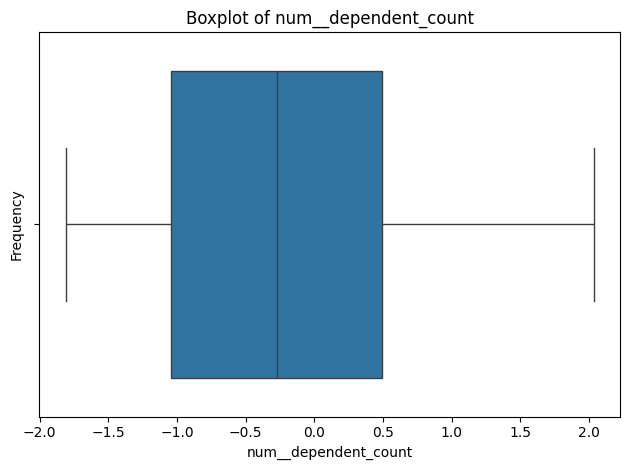

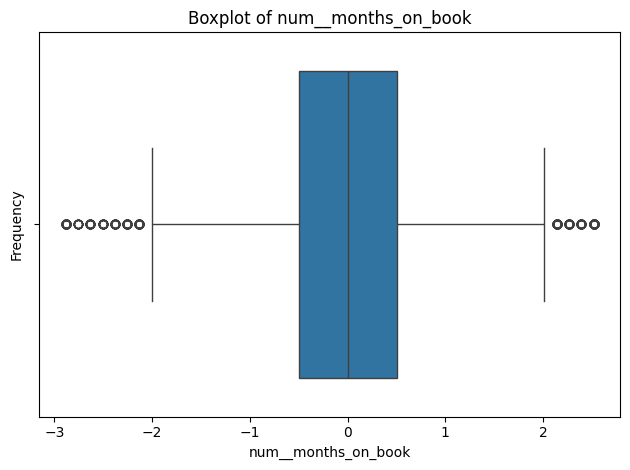

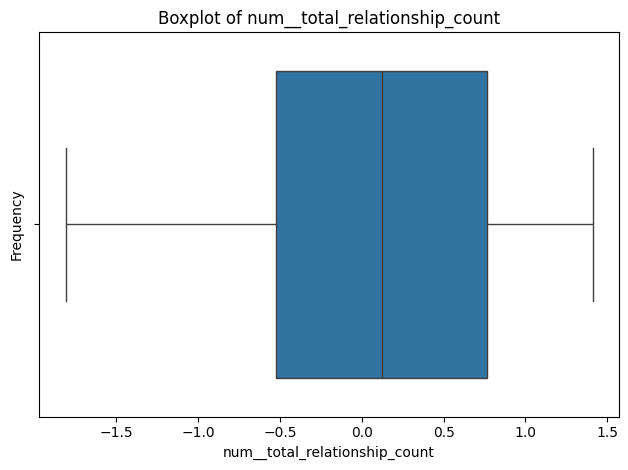

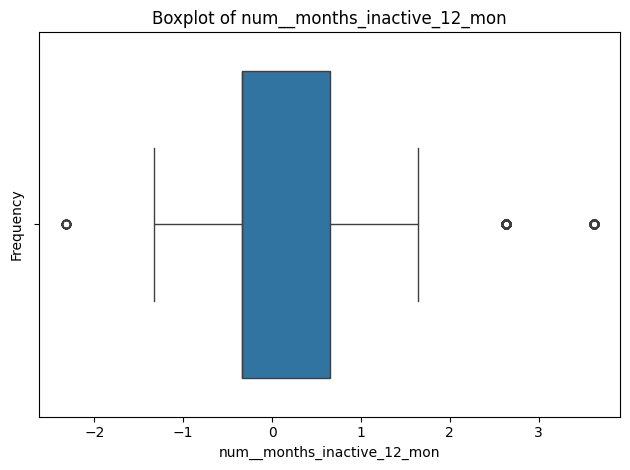

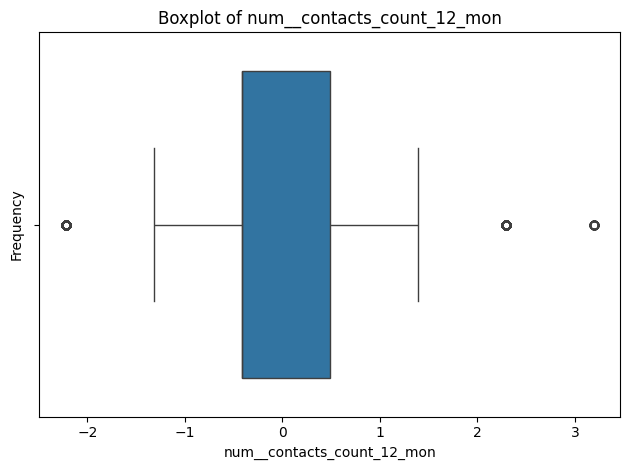

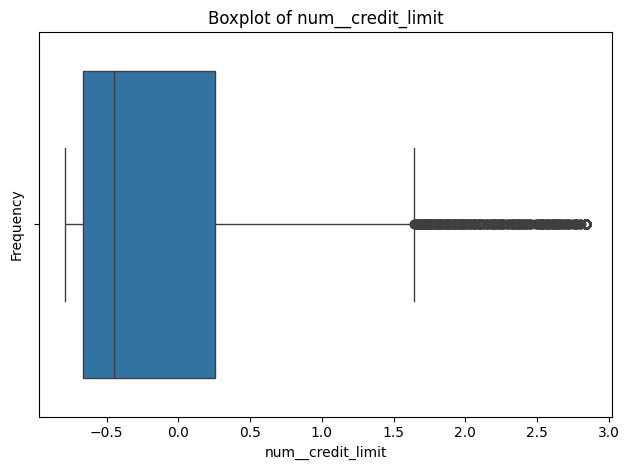

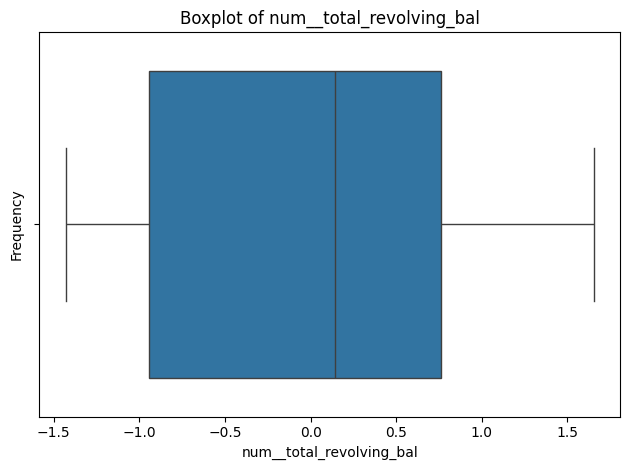

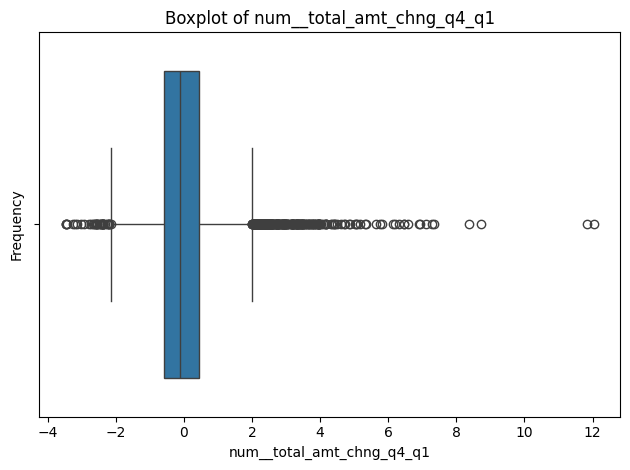

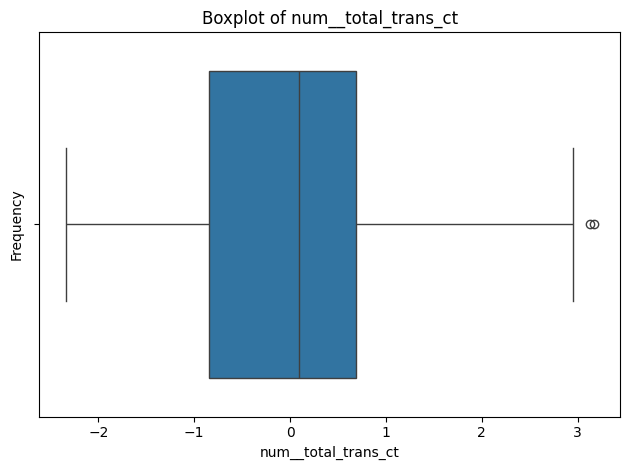

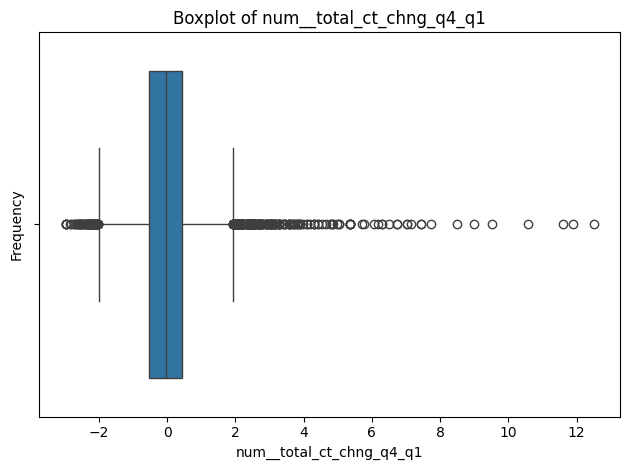

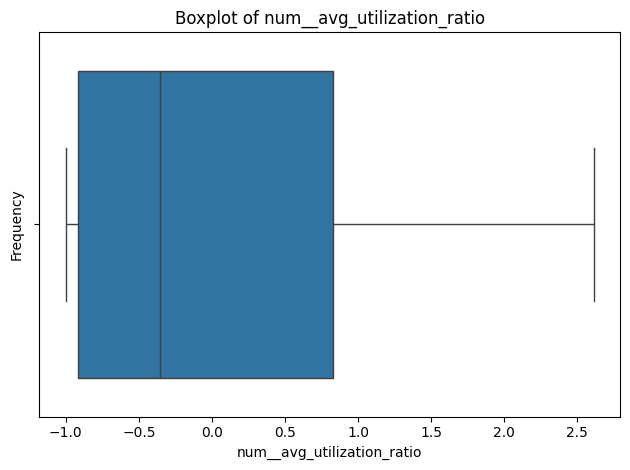

In [ ]:
for col in num_cols_1:
            sns.boxplot(data=x_train_scaled, x = col)
            plt.title(f'Boxplot of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()

## Step 3: Data Modelling

Buatlah model prediksi dengan menggunakan model machine learning (bebas, tidak dibatasi) dan evaluasi seberapa baik model yang anda buat.

### Using Basic Model First

Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
coef_lr = pd.DataFrame({
    'Features' : x_train_scaled.columns,
    'Coef' : lr.coef_[0]
})

coef_lr

,Features,Coef
0,num__dependent_count,0.163910
1,num__months_on_book,-0.074116
2,num__total_relationship_count,-0.797960
3,num__months_inactive_12_mon,0.495516
4,num__contacts_count_12_mon,0.515532
5,num__credit_limit,-0.019905
6,num__total_revolving_bal,-0.709033
7,num__total_amt_chng_q4_q1,-0.024714
8,num__total_trans_ct,-1.545938
9,num__total_ct_chng_q4_q1,-0.624316


Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 5,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)

dt.fit(x_train, y_train)
print(f'\nTree depth: {dt.get_depth()}')
print(f'Number of leaves: {dt.get_n_leaves()}')
print('\n✅ Model trained successfully!')


Tree depth: 5
Number of leaves: 25

✅ Model trained successfully!


In [ ]:
feat_importances_dt = pd.DataFrame(dt.feature_importances_, index = x_train.columns, columns = ['Importance'])

<Axes: >

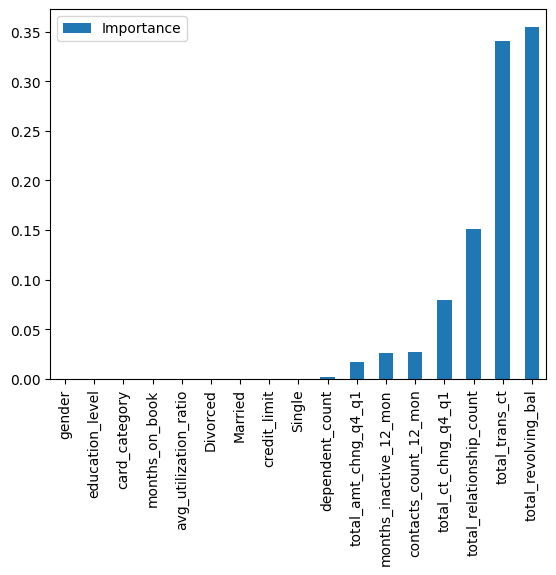

In [ ]:
feat_importances_dt.sort_values(by = 'Importance').plot(kind = 'bar')

Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
feat_importance_rf = pd.DataFrame(rf_model.feature_importances_, index = x_train.columns, columns = ['importances'])

<Axes: >

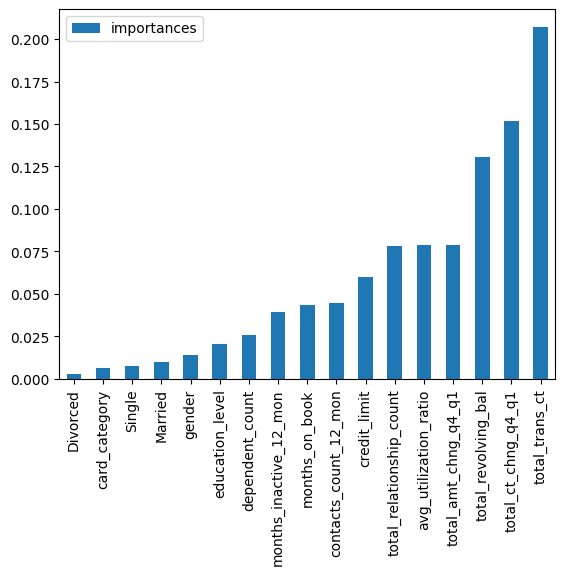

In [ ]:
feat_importance_rf.sort_values(by = 'importances').plot(kind = 'bar')

In [ ]:
feat_importance_rf

,importances
gender,0.013897
dependent_count,0.025806
education_level,0.020464
card_category,0.006109
months_on_book,0.043676
total_relationship_count,0.077964
months_inactive_12_mon,0.039601
contacts_count_12_mon,0.044890
credit_limit,0.060083
total_revolving_bal,0.130857


XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
#Ensuring all of the type are numeric

x_train_float = x_train.astype(float)

xgb.fit(x_train_float,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
feat_importance_xgb = pd.DataFrame(xgb.feature_importances_, index = x_train_float.columns, columns = ['importances'])

<Axes: >

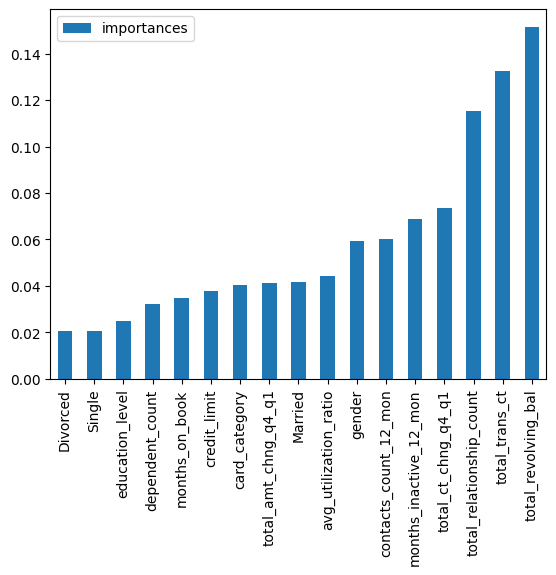

In [ ]:
feat_importance_xgb.sort_values(by = 'importances').plot(kind = 'bar')

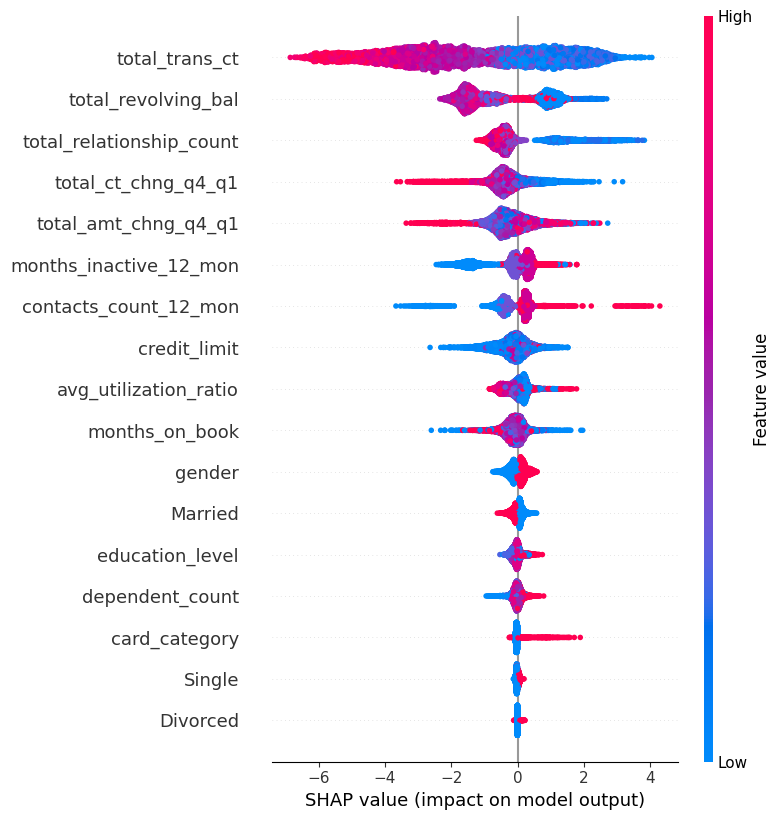

In [ ]:
import shap
# Buat explainer khusus untuk model tree seperti XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_train_float)

# Tampilkan summary plot
shap.summary_plot(shap_values, x_train_float)

### Basic Evaluation

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2026 entries, 718586133 to 713428833
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   attrition_flag            2026 non-null   object 
 1   customer_age              2026 non-null   int64  
 2   gender                    2026 non-null   object 
 3   dependent_count           2026 non-null   int64  
 4   education_level           2026 non-null   object 
 5   marital_status            2026 non-null   object 
 6   income_category           2026 non-null   object 
 7   card_category             2026 non-null   object 
 8   months_on_book            2026 non-null   int64  
 9   total_relationship_count  2026 non-null   int64  
 10  months_inactive_12_mon    2026 non-null   int64  
 11  contacts_count_12_mon     2026 non-null   int64  
 12  credit_limit              2026 non-null   float64
 13  total_revolving_bal       2026 non-null   int64  
 14  

In [ ]:
#Mapping data ordinal
test_df['attrition_flag'] = test_df['attrition_flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})
test_df['gender'] = test_df['gender'].map({'M': 0, 'F': 1})
test_df['card_category'] = test_df['card_category'].map({'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3})
test_df['education_level'] = test_df['education_level'].map({'Uneducated':0, 'High School': 1, 'College' : 2, 'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': 3})
test_df['income_category'] = test_df['income_category'].map({'Less than $40K': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +':4,  'Unknown' : 0})

In [ ]:
#Mapping data Nominal (Status pernikahan)
test_df = pd.concat([test_df,pd.get_dummies(test_df['marital_status']).drop(columns=['Unknown'])],axis=1)

In [ ]:
test_df = test_df.drop(columns = ['marital_status'])

In [ ]:
test_df = test_df.drop(columns = ['customer_age',
                                    'income_category',
                                    'avg_open_to_buy',
                                    'total_trans_amt'])

In [ ]:
test_df.head()

,attrition_flag,gender,dependent_count,education_level,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,Divorced,Married,Single
user_id,,,,,,,,,,,,,,,,,,
718586133,0,1,3,3,0,31,6,1,3,2639.0,0,0.892,85,0.771,0.000,False,True,False
710227908,0,1,3,3,0,36,3,2,3,6077.0,1397,0.834,74,0.609,0.230,False,False,True
735417408,0,0,2,1,0,30,4,1,2,2218.0,1266,0.709,58,0.568,0.571,False,True,False
719491233,0,0,1,2,0,42,6,2,3,3515.0,2517,1.051,72,0.800,0.716,False,False,True
794965233,1,1,1,3,1,45,6,3,3,13199.0,781,0.411,44,0.630,0.059,False,True,False


In [ ]:
x_test = test_df.drop(columns = ['attrition_flag'])
y_test = test_df['attrition_flag']

In [ ]:
x_test_scaled = pd.DataFrame(preprocessor.transform(x_test), columns = preprocessor.get_feature_names_out())

In [ ]:
y_test.value_counts()

,count
attrition_flag,
0,1701
1,325


Evaluate Logistic Regression

In [ ]:
y_pred_lr = lr.predict(x_test_scaled)
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1701
           1       0.75      0.56      0.64       325

    accuracy                           0.90      2026
   macro avg       0.83      0.76      0.79      2026
weighted avg       0.89      0.90      0.89      2026

[[1640   61]
 [ 144  181]]


Evaluate Decision Tree

In [ ]:
y_pred_dt = dt.predict(x_test)
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1701
           1       0.77      0.66      0.71       325

    accuracy                           0.91      2026
   macro avg       0.86      0.81      0.83      2026
weighted avg       0.91      0.91      0.91      2026

[[1639   62]
 [ 112  213]]


Evaluate Random Forest

In [ ]:
y_pred_rf = rf_model.predict(x_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1701
           1       0.84      0.70      0.76       325

    accuracy                           0.93      2026
   macro avg       0.89      0.84      0.86      2026
weighted avg       0.93      0.93      0.93      2026

[[1656   45]
 [  96  229]]


Evaluate XGB Model

In [ ]:
x_test_float = x_test.astype(float)

In [ ]:
y_pred_xgb = xgb.predict(x_test_float)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1701
           1       0.84      0.76      0.80       325

    accuracy                           0.94      2026
   macro avg       0.90      0.86      0.88      2026
weighted avg       0.94      0.94      0.94      2026

[[1654   47]
 [  79  246]]


Permutation Importances

In [ ]:
perm_importance = permutation_importance(
    xgb, x_test_float, y_test,
    n_repeats=10,
    random_state = 42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Features': x_train_float.columns,
    'Importance_mean' : perm_importance.importances_mean,
    'Importance_std' : perm_importance.importances_std
}).sort_values(by = 'Importance_mean', ascending = False).reset_index(drop = True)

print('Permutation Importance : Metrics : ROC-AUC')
print()
display(perm_df)

Permutation Importance : Metrics : ROC-AUC



,Features,Importance_mean,Importance_std
0,total_trans_ct,2.275760e-01,0.007337
1,total_revolving_bal,2.927581e-02,0.003371
2,total_relationship_count,2.530457e-02,0.001688
3,total_ct_chng_q4_q1,1.392104e-02,0.002090
4,total_amt_chng_q4_q1,1.326496e-02,0.002583
5,months_inactive_12_mon,1.126595e-02,0.001630
6,credit_limit,9.537919e-03,0.002879
7,contacts_count_12_mon,5.677203e-03,0.001428
8,months_on_book,4.688102e-03,0.000987
9,gender,2.177904e-03,0.000712


In [ ]:
perm_importance

{'importances_mean': array([ 2.17790440e-03,  1.13851581e-03,  2.47998915e-04, -2.78569167e-05,
         4.68810202e-03,  2.53045720e-02,  1.12659522e-02,  5.67720345e-03,
         9.53791887e-03,  2.92758106e-02,  1.32649573e-02,  2.27575996e-01,
         1.39210419e-02,  1.45633790e-03,  5.42667209e-07,  6.49934428e-04,
        -1.98435310e-04]),
 'importances_std': array([7.11528484e-04, 8.11006698e-04, 3.80727835e-04, 2.03598182e-04,
        9.87355792e-04, 1.68796585e-03, 1.62952349e-03, 1.42789603e-03,
        2.87890712e-03, 3.37080277e-03, 2.58284747e-03, 7.33681951e-03,
        2.09022661e-03, 5.79454892e-04, 4.32022027e-05, 4.72868421e-04,
        1.36232529e-04]),
 'importances': array([[ 1.24451680e-03,  2.83995840e-03,  1.64066386e-03,
          3.02446525e-03,  1.79622846e-03,  1.76728621e-03,
          2.88156288e-03,  2.05489983e-03,  1.28793018e-03,
          3.24153213e-03],
        [ 2.42391354e-04,  4.66693800e-04,  1.10342333e-03,
          3.03170081e-03,  1.48329

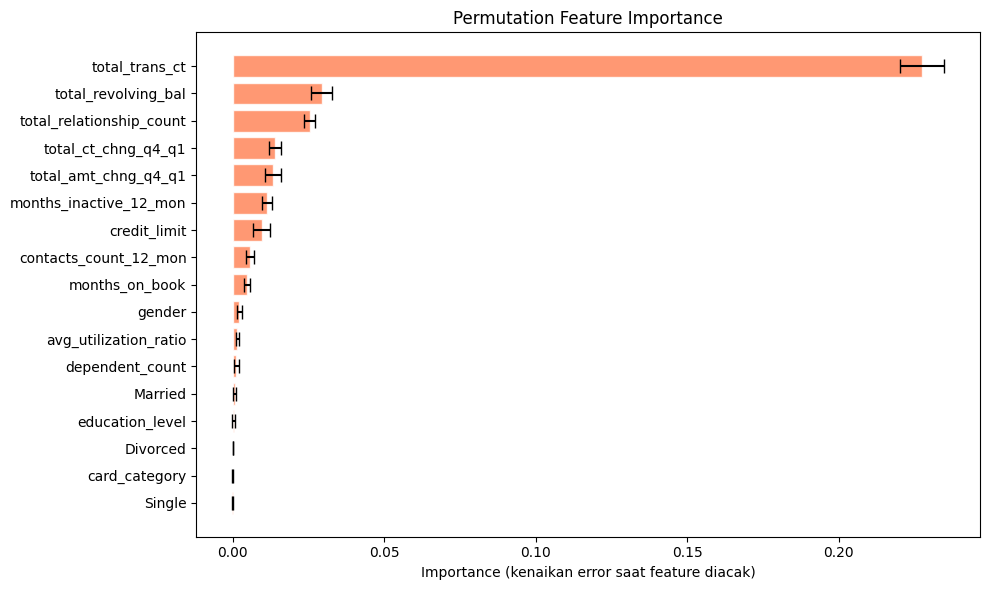

Error bars = variabilitas dari 10x pengacakan (error bar kecil = konsisten)


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(perm_df['Features'][::-1], perm_df['Importance_mean'][::-1],
         xerr=perm_df['Importance_std'][::-1],
         color='coral', alpha=0.8, capsize=5, edgecolor='white')
plt.xlabel('Importance (kenaikan error saat feature diacak)')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()
print("Error bars = variabilitas dari 10x pengacakan (error bar kecil = konsisten)")

Partial Dependence Plot

In [ ]:
importance_df = pd.DataFrame({
    'features' : x_train_float.columns,
    'importances' : xgb.feature_importances_
}).sort_values(by = 'importances', ascending = False).reset_index(drop=True)

print("XGB Feature Importances")
print("(mengukur rata-rata penurunan impurity per feature)")
print()
display(importance_df)

XGB Feature Importances
(mengukur rata-rata penurunan impurity per feature)



,features,importances
0,total_revolving_bal,0.151614
1,total_trans_ct,0.132384
2,total_relationship_count,0.115182
3,total_ct_chng_q4_q1,0.073345
4,months_inactive_12_mon,0.068931
5,contacts_count_12_mon,0.060262
6,gender,0.059233
7,avg_utilization_ratio,0.044440
8,Married,0.041785
9,total_amt_chng_q4_q1,0.041286


In [ ]:
top_features = importance_df.head(6)['features'].tolist()
print("Top 6 features:", top_features)
# boleh ambil sebagian dari top feature atau diambil semua kolom

Top 6 features: ['total_revolving_bal', 'total_trans_ct', 'total_relationship_count', 'total_ct_chng_q4_q1', 'months_inactive_12_mon', 'contacts_count_12_mon']


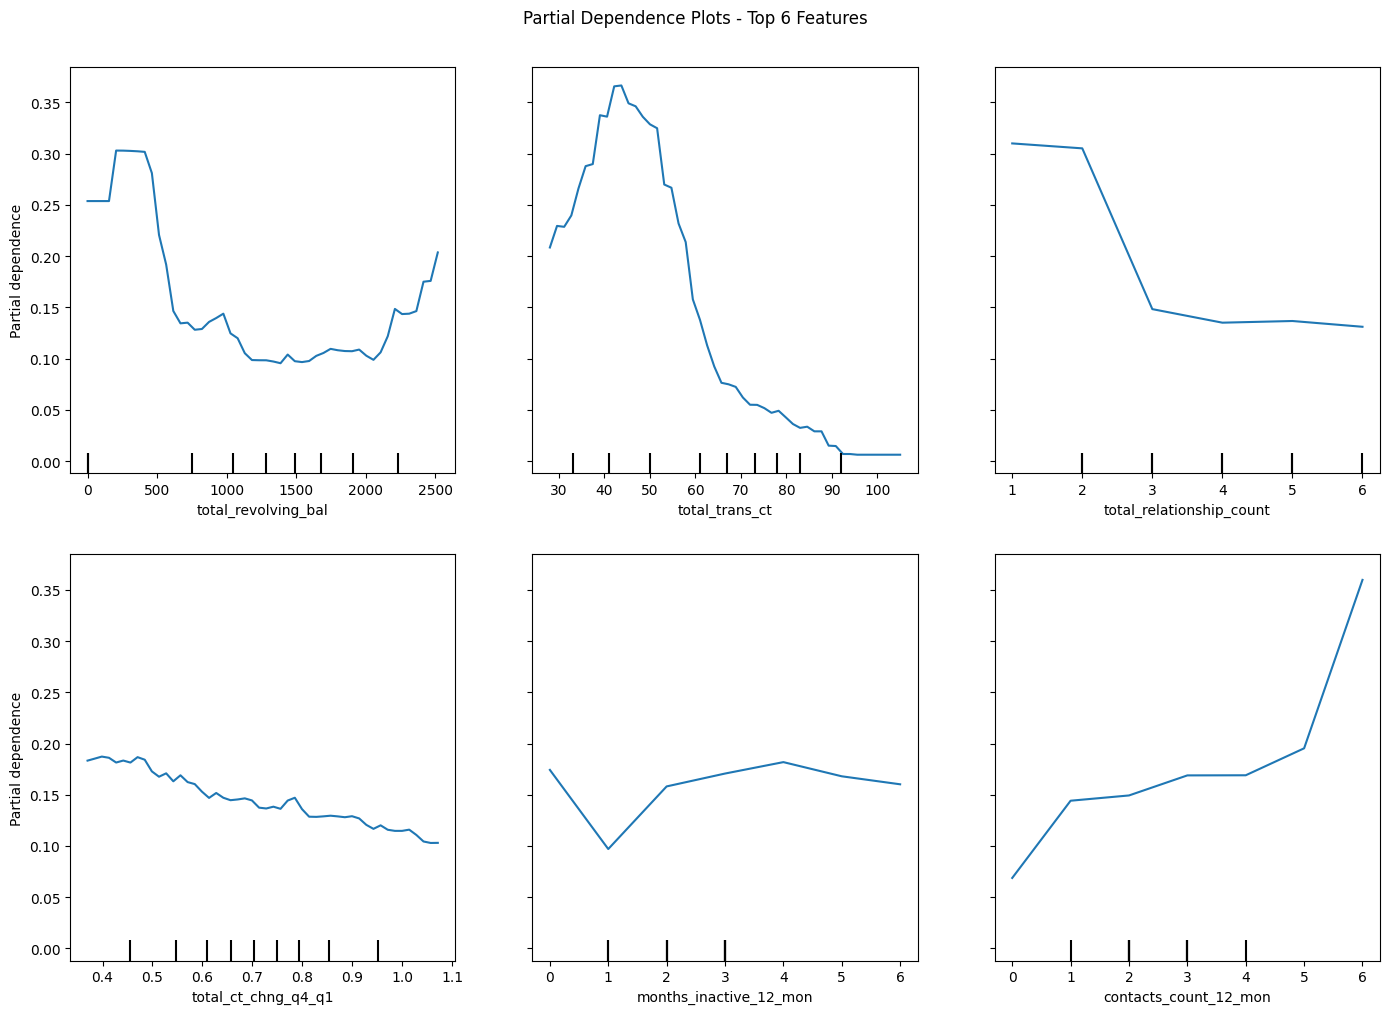

In [ ]:
# PDP
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    xgb, x_train_float, # model, data train atau data test
    features=top_features, # sebagian atau seluruh fitur
    kind='average',
    grid_resolution=50,
    ax=ax
)
plt.suptitle('Partial Dependence Plots - Top 6 Features', y=1.01)
plt.tight_layout()
plt.show()

Anda ingin meyakinkan stakeholder anda bahwa model yang anda gunakan akan lebih baik dalam mengidentifikasi customer yang akan churn dibandingkan tanpa menggunakan model. Apa metrik yang dapat anda gunakan untuk membuktikan hal ini? Visualkan!

Metrik yang digunakan untuk membuktikan hal ini adalah dengan menggunakan XGBoost. Dapat dilihat bahwa untuk penggunaan XGBoost mampu menentukan kategori=kategori mana saja yang menentukan pelanggan akan berhenti menggunakan produk dari bank tersebut. Kenapa menggunakan XGBoost ? Berdasarkan hasil dari recall dimana recall menentukan seberapa baik model menentukan pelanggan mana yang benar-benar berhenti berlangganan, recall yang diperoleh dari model XGBoost adalah 76%.

Kalau dilihat dari model XGBoost, ada 6 faktor utama yang memengaruhi keputusan apakah pelanggan akan berhenti menggunakan produk atau tidak, yaitu

1.   Frekuensi transaksi dalam 12 bulan terakhir
2.   Banyak dana yang digunakan dalam 1 periode
3.   Banyak produk yang digunakan oleh nasabah
4.   Peningkatan frekuensi transaksi dari Q4 ke Q1 tahun depan
5.   Periode tidak aktif dalam 12 bulan terakhir.
6.   Banyak interaksi dengan perbankan dalam 12 bulan terakhir.

Dari parameter yang diperoleh, dapat dipastikan bahwa:
1. Ketika dana yang digunakan dalam 1 periode melebihi \$500, maka kemungkinan nasabah tersebut akan berhenti menggunakan layanan semakin rendah, namun perlu diperhatikan apabila nasabah menggunakan dana lebih dari \$2000 karena ada indikasi berhenti berlangganan yang tinggi.
2. Semakin meningkatnya transaksi dalam 12 bulan terakhir, maka semakin kecil pelanggan tersebut akan churn. Kemungkinan nasabah akan berhenti menggunakan produk menurun drastis ketika frekuensi transaksi sudah melebihi 50.
3. Jika nasabah hanya menggunakan 1 sampai 2 produk, maka kemungkinan berhenti berlangganan masih tinggi, namun ketika sudah menggunakan minimal 3 produk, maka kemungkinan nasabah berhenti menggunakan produk menurun drastis.
4. Apabila peningkatan transaksi dari Q4 ke Q1 tahun depan meningkat minimal 40%, maka kemungkinan nasabah berhenti menggunakan layanan bank tersebut semakin kecil.
5. Apabila nasabah tidak menggunakan produk selama 1 bulan, maka masih tergolong aman karena kemungkinan berhenti menggunakan layanan masih rendah, namun perlu diperhatikan karena apabila sudah menuju 2 bulan, maka pelanggan tersebut ada indikasi untuk berhenti menggunakan produk.
6. Semakin sering nasabah menghubungi bank, semakin tinggi juga kemungkinan nasabah berhenti berlangganan.

dengan recall 76%, dari 325 nasabah yang benar-benar churn di test set, model berhasil menangkap 246 — sisa 79 yang lolos (false negative) adalah nasabah yang tetap perlu strategi retensi umum karena tidak tertangkap model.


**Rekomendasi Bisnis**

1. Pengembangan fitur untuk tracking pengeluaran nasabah merupakan prioritas dengan tujuan agar pengeluaran nasabah secara rata-rata mampu dijaga \$500 - \$2000.
2. Guna mendukung frekuensi transaksi, alangkah lebih baik ketika bank menawarkan promo reward / cashback kepada nasabah agar mau menggunakan produk bank semakin sering, contohnya dari penggunaan kartu kredit bisa mendapatkan reward untuk dikonversi menjadi miles / cashback ketika berbelanja di merchant rekanan bank tersebut.
3. Perlu adanya campaign untuk promosi produk kepada nasabah yang hanya memiliki 1 - 2 produk agar dari nasabah sendiri mampu merasakan manfaat yang lebih beragam dari produk yang dimiliki bank tersebut.
4. Ketika akhir tahun - awal tahun depan alangkah lebih baik dari pihak bank melakukan cara agar transaksi yang dilakukan oleh seorang nasabah dapat meningkat minimal 40%, seperti contoh bekerja sama dengan merchant-merchant untuk promo akhir tahun atau bisa juga dengan implementasi fitur baru dari suatu produk di akhir tahun agar membuat nasabah ingin menggunakan produk bank.
5. Apabila dari pihak nasabah sudah berhenti menggunakan produk 1 bulan, perlu tindak lanjut dari pihak bank, saran saya bisa dibagi menjadi beberapa segmentasi nasabah. Kalau nasabah menggunakan produk dasar bisa dnegan memberikan promo, kalau misalkan nasabah menggunakan produk gold / platinum bisa dengan pendekatan personal dari Relation manager agar mau aktif untuk menggunakan produk dari bank tersebut.
6. Kalau ada komplain dari nasabah, dari pihak customer service harus sigap dalam menangani masalah tersebut, perlu adanya komunikasi dengan tim Project Manager & IT produk terkait kendala yang dialami kalau masalahnya karena produk yang dimiliki dan performance. Jangan sampai dari pihak nasabah menghubungi bank karena laporan kendala karena berdasarkan data, apabila dalam 12 bulan seorang nasabah menghubungi bank sebanyak 6 kali dapat dipastikan bahwa nasabah tersebut sudah tidak ingin menggunakan produk dari bank tersebut.

**Kesimpulan**

Analisis menunjukkan bahwa *churn* (hilangnya pelanggan) terutama dipicu oleh faktor perilaku dan keterlibatan, bukan karakteristik demografis. Pelanggan yang menunjukkan aktivitas transaksi rendah, interaksi tinggi dengan layanan pelanggan, serta tren ketidakaktifan yang meningkat memiliki kemungkinan jauh lebih besar untuk berhenti menggunakan layanan.

Secara khusus, pelanggan dengan jumlah transaksi sedikit dan frekuensi kontak yang tinggi mengindikasikan adanya potensi ketidakpuasan atau kebutuhan yang belum terpenuhi, sehingga mereka termasuk dalam segmen berisiko tinggi. Selain itu, pelanggan yang tidak aktif merupakan sinyal peringatan dini akan terjadinya *churn* dan harus ditangani secara proaktif.

Berdasarkan temuan ini, perusahaan sebaiknya memprioritaskan peningkatan keterlibatan pelanggan dan kualitas layanan daripada sekadar berfokus pada demografi pelanggan. Strategi intervensi dini—seperti promosi yang ditargetkan, penawaran yang dipersonalisasi, dan dukungan pelanggan yang proaktif—dapat secara signifikan menurunkan tingkat *churn*.

Pada akhirnya, kunci untuk mengurangi *churn* terletak pada peralihan dari manajemen pelanggan yang bersifat reaktif menjadi proaktif, yaitu dengan mengidentifikasi pelanggan berisiko sejak dini dan menerapkan strategi retensi yang disesuaikan dengan kebutuhan mereka.

## Step 4 : Reflextion Question

1. Mengapa eksplorasi data (mis. analisis usia, pendidikan, gender) penting sebelum membangun model prediksi churn, dan bagaimana temuan EDA dapat mempengaruhi pemilihan fitur serta performa model? Jawab dengan contoh konkret dari dataset (mis. kelompok usia atau tingkat pendidikan yang berisiko tinggi).
2. Apa keuntungan bisnis dari memiliki model prediktif churn yang akurat dibandingkan hanya mengandalkan asumsi atau aturan bisnis sederhana? Jelaskan dampak langsung terhadap strategi retensi, pengalokasian anggaran pemasaran, atau ROI.


1. Karena dengan melakukan eksplorasi data, dari Data Scientist dapat mengetahui apa saja faktor-faktor yang memengaruhi seorang nasabah berhenti berlangganan. Sebagai contoh dari analisis data diketahui banyak pelanggan yang menghubungi bank atas kendala yang dialami. Kalau semakin sering nasabah menghubungi bank , maka nasabah semakin ingin berhenti berlangganan.
2. Kalau bisnis memiliki model prediktif churn yang akurat, maka tim bisnis dapat mengetahui dengan jelas mana saja nasabah yang perlu dilakukan pendekatan khusus. Retensi nasabah juga bisa diketahui pasti dengan detail, pengalokasian anggaran pemasaran juga bisa lebih tepat untuk mencegah nasabah berhenti berlangganan, dan ROI dari nasabah meningkat karena tujuan pengalokasian dana ke nasabah yang berpotensi berhenti berlangganan jadi efektif dan tidak memakan banyak biaya atas kesalahan target.